# EDA: RUSH Gait Pipeline Outputs

Analyzes `all_bouts.csv` (bout-level) and `subject_summary.csv` (subject-level) produced by `aggregate_subjects.py`.

**Sections:**
1. Setup & Data Loading
2. Bout-level: Shape, Missing Values, Basic Stats
3. Bout-level: Distribution Plots
4. Bout-level: Outlier Detection (`bout_pa_mean` focus)
5. Bout-level: Correlations
6. Subject-level: Shape, Missing Values, Basic Stats
7. Subject-level: Key Metric Distributions
8. Subject-level: Outlier Subjects
9. Cross-level: Bout Counts vs Summary Stats

In [1]:
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')
from IPython.display import display
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (12, 5)

## 1. Setup & Data Loading

In [2]:
# ── Adjust these paths if your files live elsewhere ──────────────────────────
# The notebook searches the script directory first, then common subdirs.
SCRIPT_DIR = Path('.')   # directory this notebook lives in

def find_csv(name: str) -> Path:
    candidates = [
        SCRIPT_DIR / name,
        SCRIPT_DIR / 'output' / name,
        SCRIPT_DIR / 'data' / name,
    ]
    # Also search all immediate subdirectories
    for sub in SCRIPT_DIR.iterdir():
        if sub.is_dir():
            candidates.append(sub / name)
    for p in candidates:
        if p.exists():
            return p
    raise FileNotFoundError(
        f"Could not find '{name}'. Searched:\n" + '\n'.join(str(c) for c in candidates)
    )

bouts_path   = find_csv('all_bouts.csv')
summary_path = find_csv('subject_summary.csv')

print(f'Bouts file   : {bouts_path}')
print(f'Summary file : {summary_path}')

Bouts file   : outputs\all_bouts.csv
Summary file : outputs\subject_summary.csv


In [3]:
bouts   = pd.read_csv(bouts_path,   low_memory=False)
summary = pd.read_csv(summary_path, low_memory=False)

# Parse timestamps if present
if 'start_time' in bouts.columns:
    bouts['start_time'] = pd.to_datetime(bouts['start_time'], errors='coerce')
    bouts['hour']       = bouts['start_time'].dt.hour
    bouts['date']       = bouts['start_time'].dt.date

print(f'Bouts   : {bouts.shape[0]:,} rows × {bouts.shape[1]} columns')
print(f'Summary : {summary.shape[0]:,} rows × {summary.shape[1]} columns')

Bouts   : 2,303,207 rows × 23 columns
Summary : 1,998 rows × 625 columns


## 2. Bout-level: Shape, Missing Values & Basic Stats

In [4]:
# ── Missing values ────────────────────────────────────────────────────────────
miss = bouts.isnull().sum()
miss = miss[miss > 0].sort_values(ascending=False)

if miss.empty:
    print('No missing values in bouts.')
else:
    miss_pct = (miss / len(bouts) * 100).round(1)
    display(
        pd.DataFrame({'missing_n': miss, 'missing_%': miss_pct})
        .style.background_gradient(cmap='OrRd', subset=['missing_%'])
    )

,missing_n,missing_%
psd_width,57459,2.500000
psd_slope,57459,2.500000


In [5]:
# ── Core bout metrics ─────────────────────────────────────────────────────────
BOUT_METRICS = [
    'duration_sec', 'speed', 'cadence',
    'gait_length', 'gait_length_indirect',
    'regularity_eldernet', 'regularity_sp',
    'entropy', 'dom_freq', 'psd_amp', 'psd_width', 'psd_slope',
    'bout_pa_mean', 'bout_pa_std', 'total_steps',
]
# Keep only columns that exist
BOUT_METRICS = [c for c in BOUT_METRICS if c in bouts.columns]

desc = bouts[BOUT_METRICS].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).T
desc = desc.round(4)
display(desc.style.background_gradient(cmap='Blues', subset=['mean', 'std']))

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
duration_sec,2303207.000000,27.289100,52.553000,10.000000,10.000000,10.000000,12.000000,17.000000,26.000000,71.000000,177.000000,5136.000000
speed,2303207.000000,0.593500,0.246100,0.033800,0.134700,0.231300,0.423800,0.557600,0.737700,1.051700,1.291700,1.628900
cadence,2303207.000000,94.424400,14.777600,52.250400,67.433500,72.510000,82.969800,92.829800,105.259700,119.861600,128.867500,148.794000
gait_length,2303207.000000,0.927900,0.174300,0.240800,0.559900,0.650200,0.802600,0.922700,1.049500,1.217400,1.337500,1.624400
gait_length_indirect,2303207.000000,0.736300,0.230200,0.055600,0.208900,0.346100,0.586300,0.726100,0.891200,1.120500,1.286700,2.900300
regularity_eldernet,2303207.000000,0.277900,0.127100,0.026100,0.080500,0.122000,0.191000,0.247800,0.335500,0.542700,0.683100,0.850600
regularity_sp,2303207.000000,0.202500,0.149400,0.000000,0.021600,0.041000,0.092400,0.159400,0.271900,0.514600,0.692500,0.976500
entropy,2303207.000000,1.333600,0.381300,0.017600,0.390400,0.644000,1.106400,1.359200,1.576000,1.930900,2.259600,3.202100
dom_freq,2303207.000000,1.925700,0.947000,0.585900,0.703100,0.820300,1.406200,1.640600,1.992200,3.984400,5.507800,5.976600
psd_amp,2303207.000000,0.020500,0.049100,0.000000,0.000200,0.001200,0.005200,0.010800,0.022100,0.065700,0.150800,7.551900


## 3. Bout-level: Distribution Plots

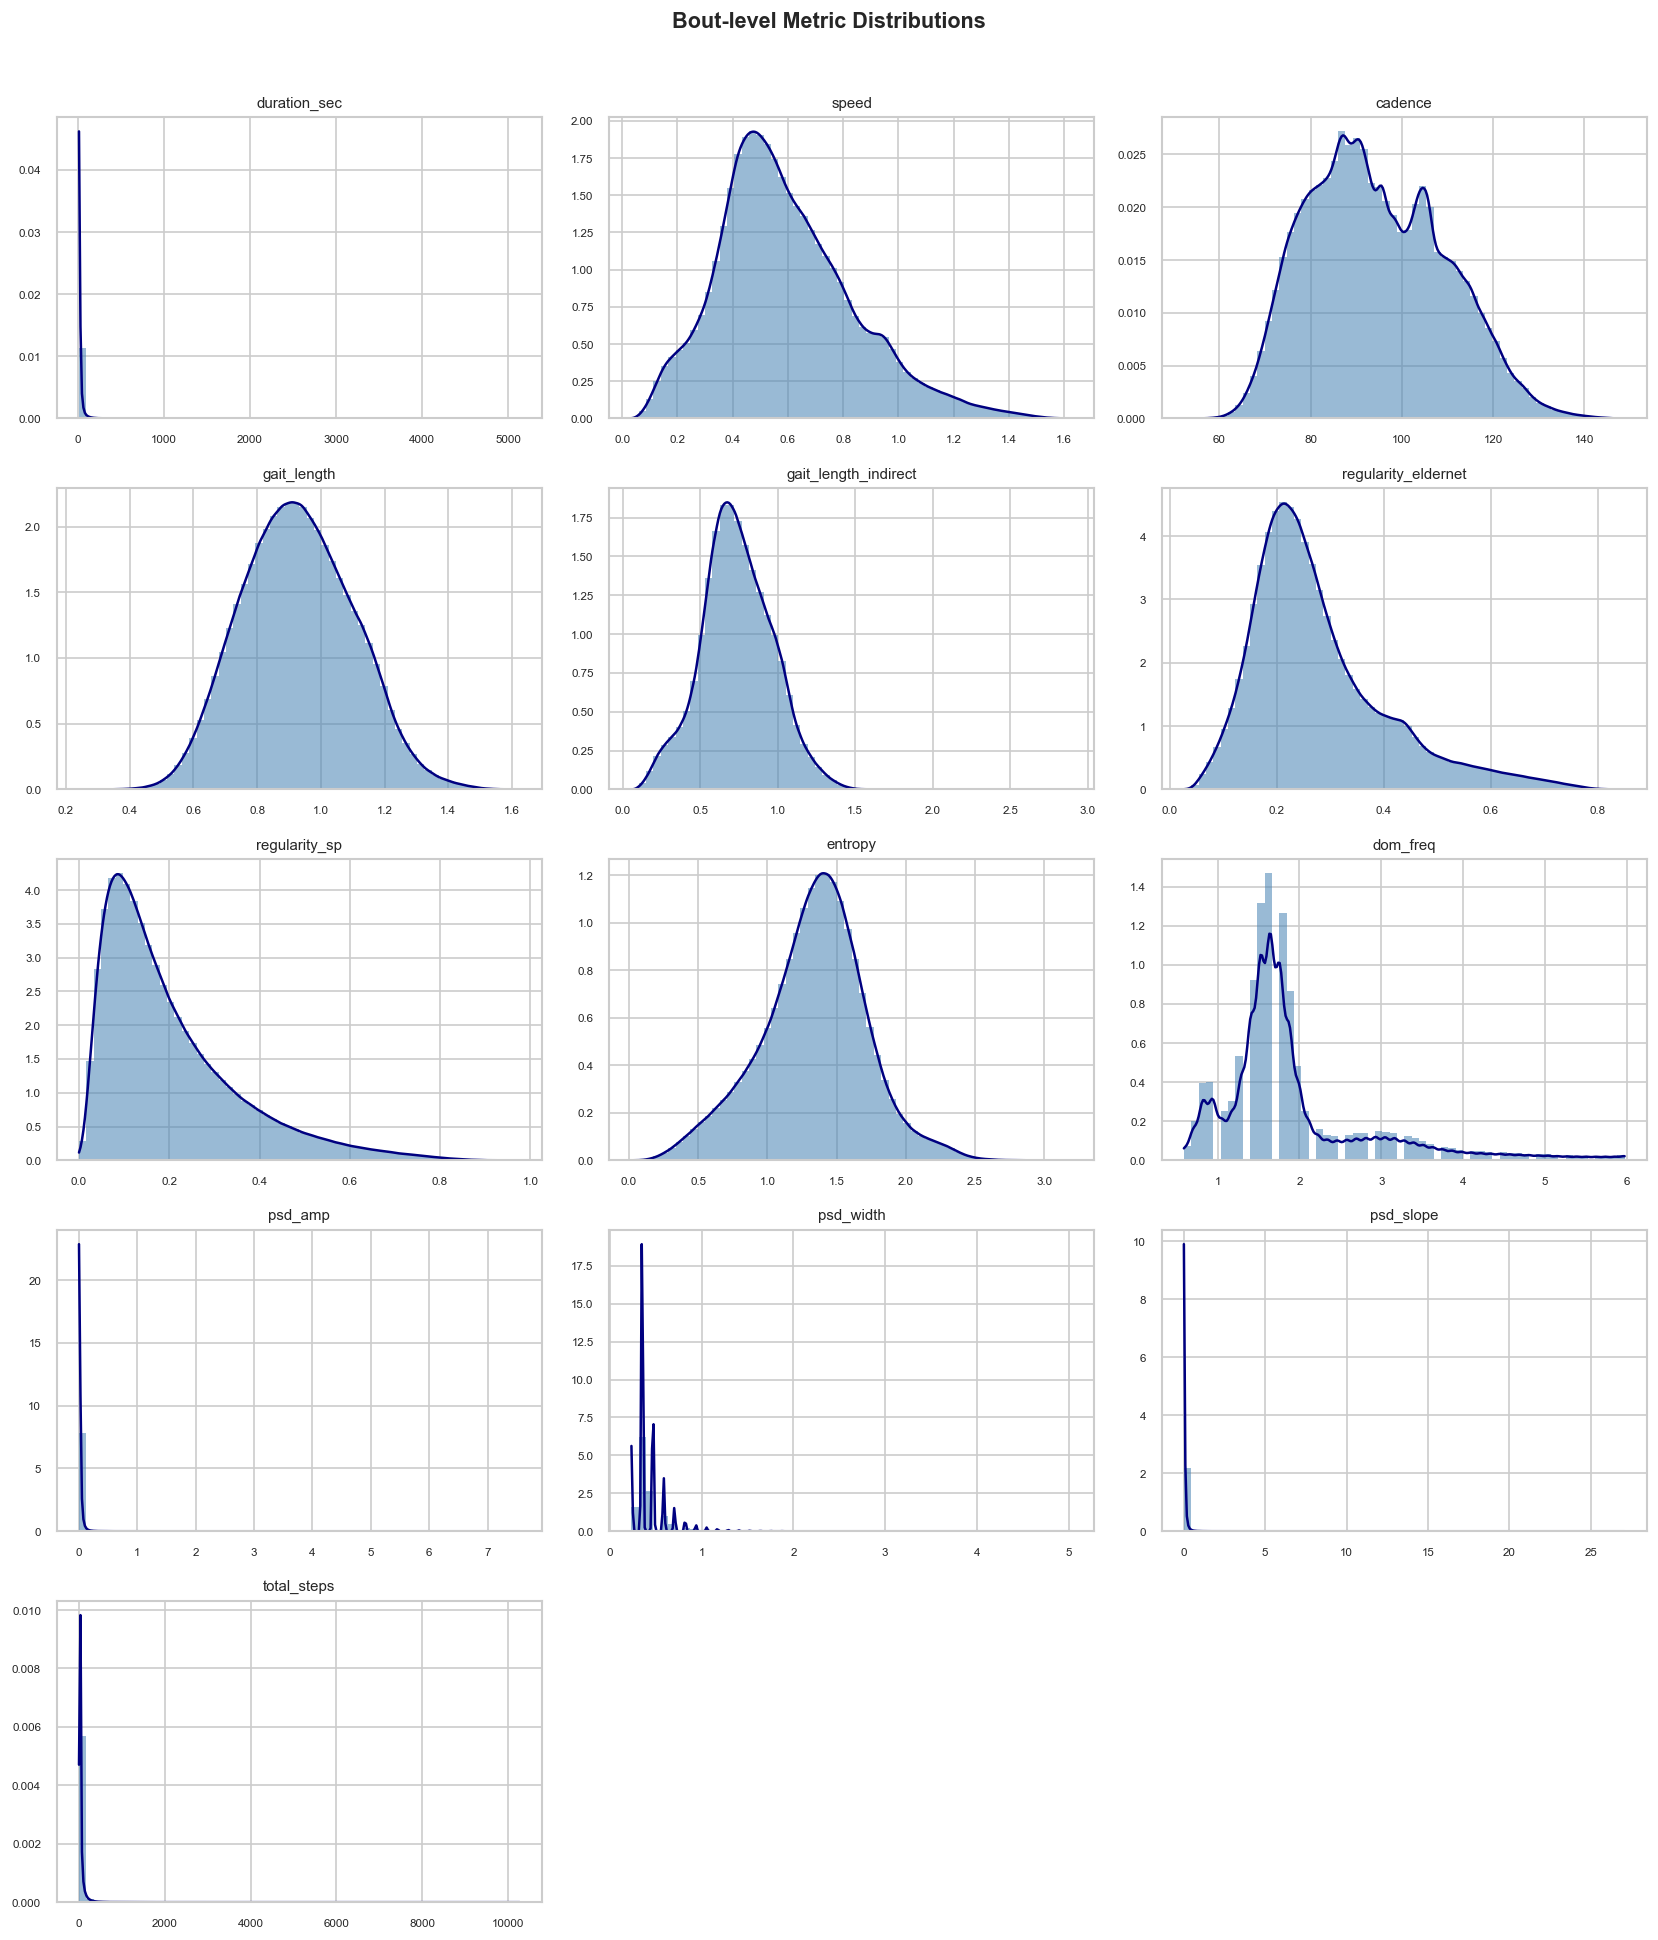

In [6]:
# ── Histograms + KDE for all core metrics ─────────────────────────────────────
ncols = 3
nrows = int(np.ceil(len(BOUT_METRICS) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(14, nrows * 3.2))
axes = axes.flatten()

for ax, col in zip(axes, BOUT_METRICS):
    data = bouts[col].dropna()
    ax.hist(data, bins=60, density=True, alpha=0.55, color='steelblue', edgecolor='none')
    try:
        from scipy.stats import gaussian_kde
        kde = gaussian_kde(data)
        xs  = np.linspace(data.min(), data.max(), 300)
        ax.plot(xs, kde(xs), color='navy', lw=1.5)
    except Exception:
        pass
    ax.set_title(col, fontsize=9)
    ax.set_xlabel('')
    ax.tick_params(labelsize=7)

for ax in axes[len(BOUT_METRICS):]:
    ax.set_visible(False)

fig.suptitle('Bout-level Metric Distributions', y=1.01, fontsize=13, fontweight='bold')
fig.tight_layout()
plt.show()

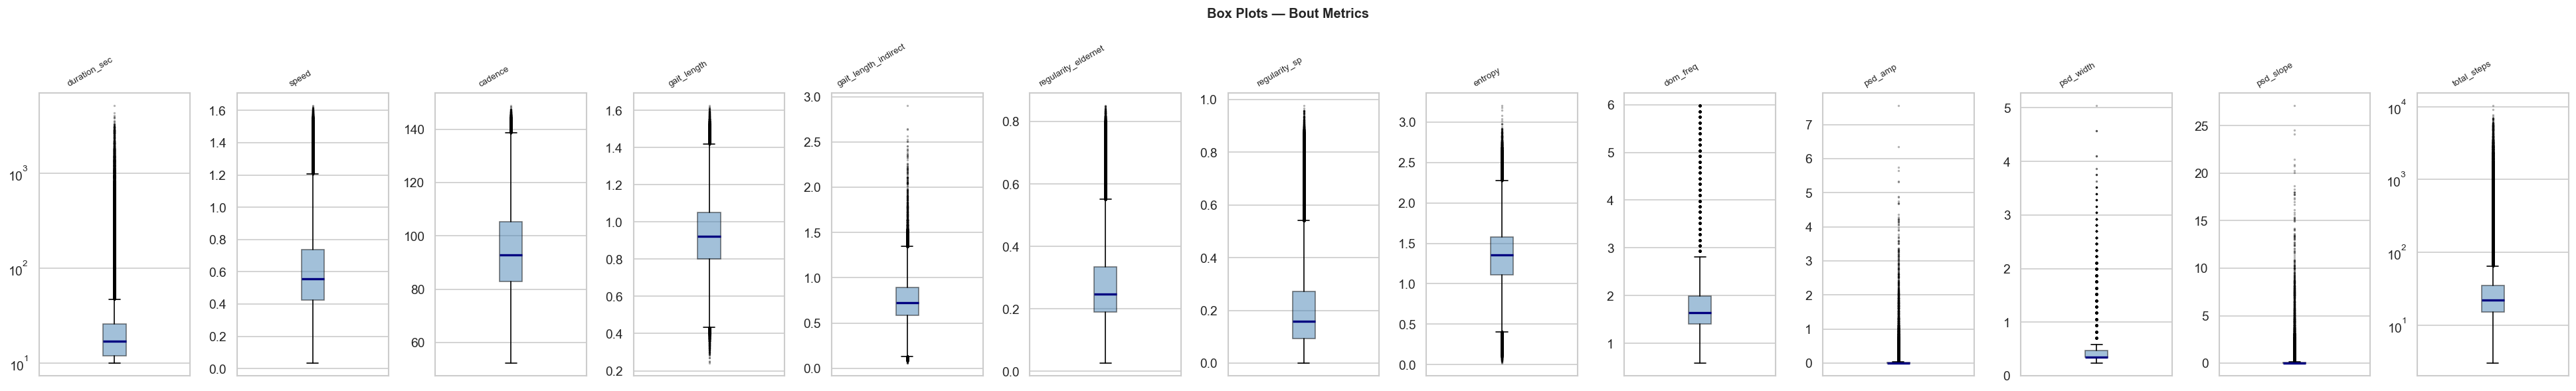

In [7]:
# ── Box plots (log-scale duration & steps for readability) ───────────────────
fig, axes = plt.subplots(1, len(BOUT_METRICS), figsize=(2.5 * len(BOUT_METRICS), 5))
if len(BOUT_METRICS) == 1:
    axes = [axes]

for ax, col in zip(axes, BOUT_METRICS):
    data = bouts[col].dropna()
    ax.boxplot(data, vert=True, patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.5),
               medianprops=dict(color='navy', lw=2),
               flierprops=dict(marker='.', markersize=2, alpha=0.3))
    ax.set_title(col, fontsize=8, rotation=30, ha='right')
    ax.set_xticks([])
    if col in ('duration_sec', 'total_steps'):
        ax.set_yscale('log')

fig.suptitle('Box Plots — Bout Metrics', fontsize=12, fontweight='bold')
fig.tight_layout()
plt.show()

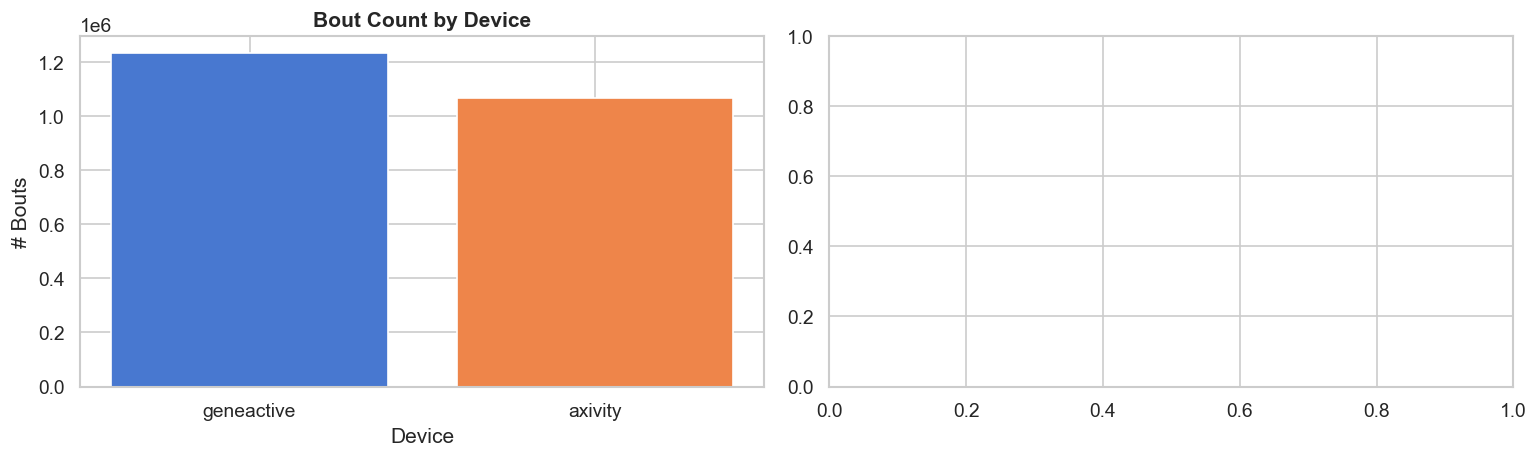

In [8]:
# ── Bout counts by device (if column exists) ──────────────────────────────────
if 'device' in bouts.columns:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    dev_counts = bouts['device'].value_counts()
    axes[0].bar(dev_counts.index, dev_counts.values, color=sns.color_palette('muted', len(dev_counts)))
    axes[0].set_title('Bout Count by Device', fontweight='bold')
    axes[0].set_xlabel('Device')
    axes[0].set_ylabel('# Bouts')

    if 'bout_pa_mean' in bouts.columns:
        bouts.boxplot(column='bout_pa_mean', by='device', ax=axes[1],
                      patch_artist=True,
                      flierprops=dict(marker='.', markersize=2, alpha=0.3))
        axes[1].set_title('bout_pa_mean by Device', fontweight='bold')
        axes[1].set_xlabel('Device')
        plt.sca(axes[1])
        plt.title('bout_pa_mean by Device')

    fig.tight_layout()
    plt.show()
else:
    print('No "device" column — skipping device split.')

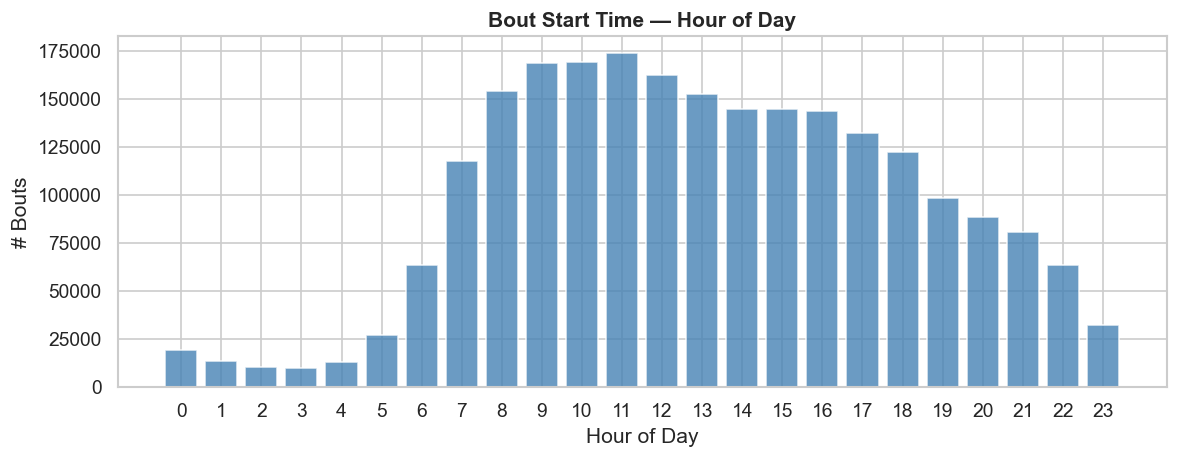

In [9]:
# ── Time-of-day distribution ──────────────────────────────────────────────────
if 'hour' in bouts.columns:
    fig, ax = plt.subplots(figsize=(10, 4))
    hour_counts = bouts['hour'].value_counts().sort_index()
    ax.bar(hour_counts.index, hour_counts.values, color='steelblue', alpha=0.8)
    ax.set_xlabel('Hour of Day')
    ax.set_ylabel('# Bouts')
    ax.set_title('Bout Start Time — Hour of Day', fontweight='bold')
    ax.set_xticks(range(0, 24))
    plt.tight_layout()
    plt.show()

## 4. Bout-level: Outlier Detection

Focus on `bout_pa_mean` (gait bouts with implausibly low physical activity) and other metrics.

Thresholds used:
- **Physiological lower bounds** for `bout_pa_mean` (< 0.8 g), `speed_median` (< 0.1 m/s), `cadence_median` (< 40 steps/min)
- **IQR rule** (1.5 × IQR) flagging per metric
- **Z-score** |z| > 3.5

In [10]:
# ── Physiological bounds ─────────────────────────────────────────────────────
PHYS_BOUNDS = {
    'bout_pa_mean':              {'low': 0.8,  'high': 4.0},
    'speed':              {'low': 0.1,  'high': 2.5},
    'cadence':            {'low': 40,   'high': 180},
    'gait_length':        {'low': 0.05, 'high': 2.5},
    'gait_length_indirect':      {'low': 0.05, 'high': 2.5},
    'regularity_eldernet_median':{'low': 0.0,  'high': 1.0},
    'regularity_sp':             {'low': 0.0,  'high': 1.0},
    'dom_freq':                  {'low': 0.3,  'high': 5.0},
    'duration_sec':              {'low': 5,    'high': 7200},
}

phys_flag_rows = {}
for col, bounds in PHYS_BOUNDS.items():
    if col not in bouts.columns:
        continue
    mask = (bouts[col] < bounds['low']) | (bouts[col] > bounds['high'])
    phys_flag_rows[col] = bouts.index[mask].tolist()

phys_summary = pd.DataFrame([
    {
        'metric': col,
        'low_bound': PHYS_BOUNDS[col]['low'],
        'high_bound': PHYS_BOUNDS[col]['high'],
        'n_flagged': len(rows),
        'pct_flagged': round(len(rows) / len(bouts) * 100, 2),
    }
    for col, rows in phys_flag_rows.items()
])
display(phys_summary.style.background_gradient(cmap='OrRd', subset=['pct_flagged']))

,metric,low_bound,high_bound,n_flagged,pct_flagged
0,speed,0.100000,2.500000,6482,0.280000
1,cadence,40.000000,180.000000,0,0.000000
2,gait_length,0.050000,2.500000,0,0.000000
3,gait_length_indirect,0.050000,2.500000,7,0.000000
4,regularity_sp,0.000000,1.000000,0,0.000000
5,dom_freq,0.300000,5.000000,46332,2.010000
6,duration_sec,5.000000,7200.000000,0,0.000000


In [12]:
# ── Deep-dive: bout_pa_mean ───────────────────────────────────────────────────
if 'bout_pa_mean' in bouts.columns:
    pa = bouts['bout_pa_mean'].dropna()

    LOW_PA_THRESH  = 0.8   # below resting-level accelerometry in gait context
    HIGH_PA_THRESH = 4.0

    low_pa_mask  = bouts['bout_pa_mean'] < LOW_PA_THRESH
    high_pa_mask = bouts['bout_pa_mean'] > HIGH_PA_THRESH

    print(f'bout_pa_mean summary')
    print(f'  Total bouts         : {len(pa):,}')
    print(f'  < {LOW_PA_THRESH} g (suspiciously low): {low_pa_mask.sum():,}  ({low_pa_mask.mean()*100:.2f}%)')
    print(f'  > {HIGH_PA_THRESH} g (suspiciously high): {high_pa_mask.sum():,}  ({high_pa_mask.mean()*100:.2f}%)')

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # Full distribution
    axes[0].hist(pa, bins=80, color='steelblue', alpha=0.7, edgecolor='none')
    axes[0].axvline(LOW_PA_THRESH,  color='red',    lw=1.5, ls='--', label=f'Low bound ({LOW_PA_THRESH}g)')
    axes[0].axvline(HIGH_PA_THRESH, color='orange', lw=1.5, ls='--', label=f'High bound ({HIGH_PA_THRESH}g)')
    axes[0].set_title('bout_pa_mean — full range')
    axes[0].set_xlabel('bout_pa_mean (g)')
    axes[0].legend(fontsize=8)

    # Left tail zoom
    axes[1].hist(pa[pa < 1.2], bins=60, color='crimson', alpha=0.7, edgecolor='none')
    axes[1].axvline(LOW_PA_THRESH, color='black', lw=1.5, ls='--')
    axes[1].set_title(f'Left tail zoom (< 1.2 g)  •  {(pa < 1.2).sum():,} bouts')
    axes[1].set_xlabel('bout_pa_mean (g)')

    # Scatter: pa_mean vs duration
    if 'duration_sec' in bouts.columns:
        sc = axes[2].scatter(
            bouts.loc[~low_pa_mask, 'duration_sec'],
            bouts.loc[~low_pa_mask, 'bout_pa_mean'],
            s=2, alpha=0.15, color='steelblue', label='Normal'
        )
        axes[2].scatter(
            bouts.loc[low_pa_mask, 'duration_sec'],
            bouts.loc[low_pa_mask, 'bout_pa_mean'],
            s=12, alpha=0.7, color='red', marker='x', label=f'< {LOW_PA_THRESH}g'
        )
        axes[2].set_xscale('log')
        axes[2].set_xlabel('duration_sec (log)')
        axes[2].set_ylabel('bout_pa_mean (g)')
        axes[2].set_title('PA mean vs Duration')
        axes[2].legend(fontsize=8)

    fig.suptitle('bout_pa_mean Outlier Analysis', fontsize=12, fontweight='bold')
    fig.tight_layout()
    plt.show()

In [13]:
# ── Low-PA outlier profile ────────────────────────────────────────────────────
if 'bout_pa_mean' in bouts.columns:
    compare_cols = ['duration_sec', 'speed_median', 'cadence_median',
                    'gait_length_median', 'regularity_eldernet_median',
                    'entropy', 'total_steps']
    compare_cols = [c for c in compare_cols if c in bouts.columns]

    normal   = bouts[~low_pa_mask][compare_cols]
    outliers = bouts[low_pa_mask][compare_cols]

    if not outliers.empty:
        comparison = pd.DataFrame({
            'normal_median':   normal.median(),
            'normal_mean':     normal.mean(),
            'outlier_median':  outliers.median(),
            'outlier_mean':    outliers.mean(),
        }).round(4)
        comparison['median_ratio'] = (comparison['outlier_median'] / comparison['normal_median']).round(3)
        print(f'Profile of {low_pa_mask.sum()} low-PA bouts (bout_pa_mean < {LOW_PA_THRESH}g) vs rest:')
        display(comparison.style.background_gradient(cmap='RdYlGn_r', subset=['median_ratio']))
    else:
        print('No low-PA bouts found with current threshold.')

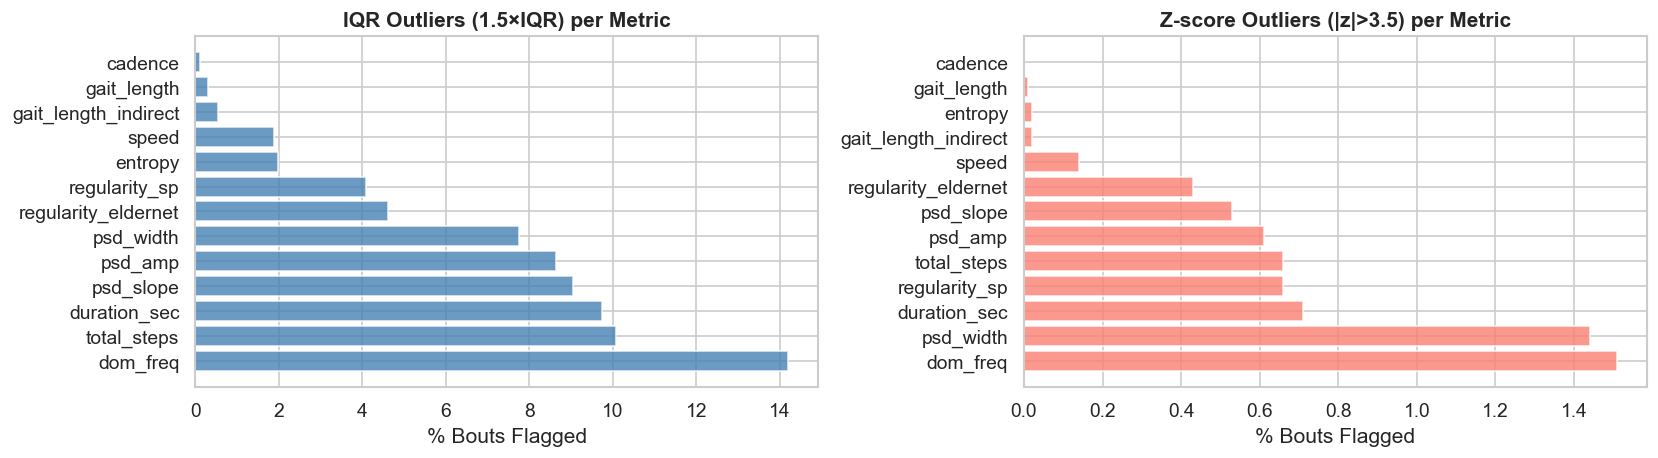

In [14]:
# ── IQR outlier flags across all metrics ─────────────────────────────────────
def iqr_outlier_mask(series, k=1.5):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr     = q3 - q1
    return (series < q1 - k * iqr) | (series > q3 + k * iqr)

def zscore_outlier_mask(series, threshold=3.5):
    z = np.abs(stats.zscore(series.dropna()))
    flags = pd.Series(False, index=series.index)
    flags.loc[series.dropna().index] = z > threshold
    return flags

iqr_report = []
z_report   = []

for col in BOUT_METRICS:
    if col not in bouts.columns:
        continue
    s = bouts[col]
    iqr_n = iqr_outlier_mask(s).sum()
    z_n   = zscore_outlier_mask(s).sum()
    iqr_report.append({'metric': col, 'n_iqr_outliers': iqr_n, 'pct': round(iqr_n / len(s) * 100, 2)})
    z_report.append(  {'metric': col, 'n_z_outliers':   z_n,   'pct': round(z_n   / len(s) * 100, 2)})

iqr_df = pd.DataFrame(iqr_report).sort_values('pct', ascending=False)
z_df   = pd.DataFrame(z_report).sort_values('pct', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].barh(iqr_df['metric'], iqr_df['pct'], color='steelblue', alpha=0.8)
axes[0].set_xlabel('% Bouts Flagged')
axes[0].set_title('IQR Outliers (1.5×IQR) per Metric', fontweight='bold')
axes[1].barh(z_df['metric'], z_df['pct'], color='salmon', alpha=0.8)
axes[1].set_xlabel('% Bouts Flagged')
axes[1].set_title('Z-score Outliers (|z|>3.5) per Metric', fontweight='bold')
fig.tight_layout()
plt.show()

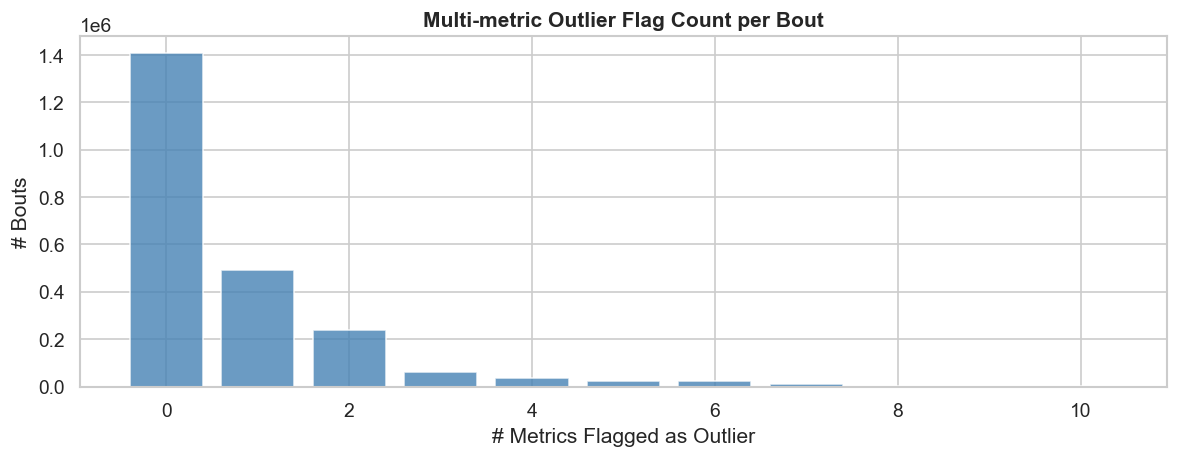


Bouts flagged on ≥4 metrics: 97,637


KeyError: "['speed_median', 'cadence_median', 'bout_pa_mean'] not in index"

In [15]:
# ── Multi-flag outlier bouts ─────────────────────────────────────────────────
# A bout flagged as outlier on many metrics simultaneously is most suspicious.
flag_matrix = pd.DataFrame(index=bouts.index)
for col in BOUT_METRICS:
    if col in bouts.columns:
        flag_matrix[col] = iqr_outlier_mask(bouts[col]).astype(int)

bouts['n_outlier_flags'] = flag_matrix.sum(axis=1)

fig, ax = plt.subplots(figsize=(10, 4))
counts = bouts['n_outlier_flags'].value_counts().sort_index()
ax.bar(counts.index, counts.values, color='steelblue', alpha=0.8)
ax.set_xlabel('# Metrics Flagged as Outlier')
ax.set_ylabel('# Bouts')
ax.set_title('Multi-metric Outlier Flag Count per Bout', fontweight='bold')
plt.tight_layout()
plt.show()

threshold_flags = 4
multi_outliers = bouts[bouts['n_outlier_flags'] >= threshold_flags]
print(f'\nBouts flagged on ≥{threshold_flags} metrics: {len(multi_outliers):,}')
if not multi_outliers.empty:
    display(multi_outliers[['start_time', 'duration_sec', 'speed_median',
                             'cadence_median', 'bout_pa_mean', 'n_outlier_flags']
                            + (['device'] if 'device' in multi_outliers.columns else [])
                            + (['subject_id'] if 'subject_id' in multi_outliers.columns else [])]
            .sort_values('n_outlier_flags', ascending=False)
            .head(20)
            .reset_index(drop=True))

## 5. Bout-level: Correlations

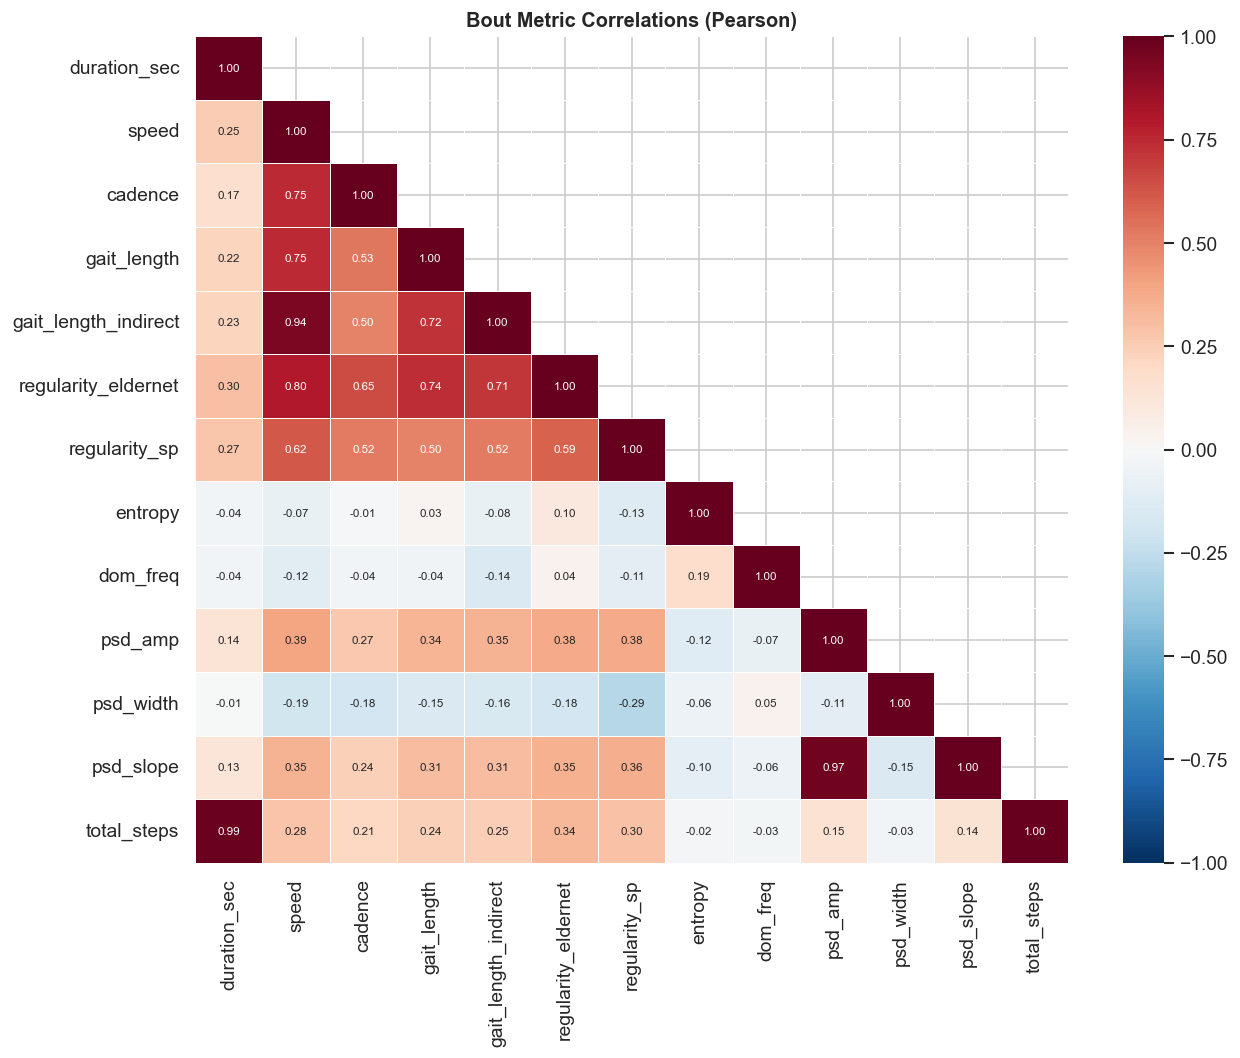

In [16]:
corr_cols = [c for c in BOUT_METRICS if c in bouts.columns]
corr = bouts[corr_cols].corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    linewidths=0.4, ax=ax, annot_kws={'size': 7}
)
ax.set_title('Bout Metric Correlations (Pearson)', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

<Figure size 1440x1200 with 0 Axes>

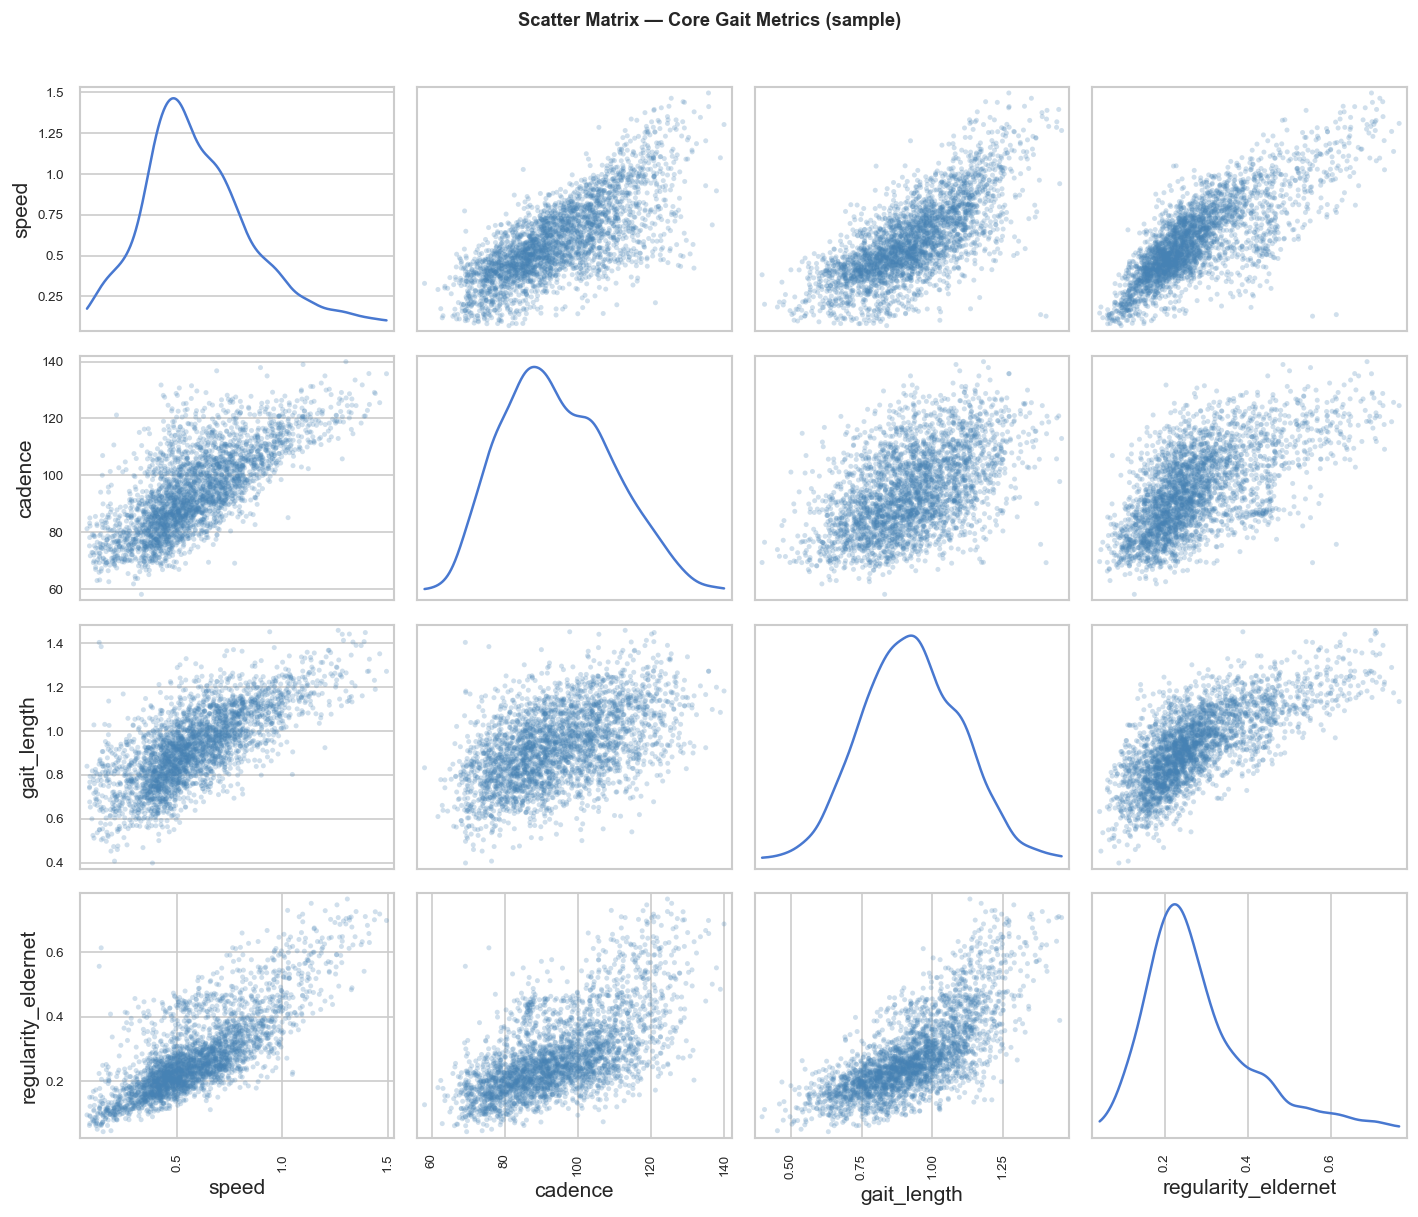

In [17]:
# ── Scatter matrix for core gait metrics ─────────────────────────────────────
core = ['speed', 'cadence', 'gait_length',
        'regularity_eldernet', 'bout_pa_mean']
core = [c for c in core if c in bouts.columns]

sample = bouts[core].dropna().sample(min(3000, len(bouts)), random_state=42)

fig = plt.figure(figsize=(12, 10))
pd.plotting.scatter_matrix(
    sample, alpha=0.25, figsize=(12, 10), diagonal='kde',
    color='steelblue'
)
plt.suptitle('Scatter Matrix — Core Gait Metrics (sample)', fontsize=11, y=1.01, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Subject-level: Shape, Missing Values & Basic Stats

87 columns have missing values.


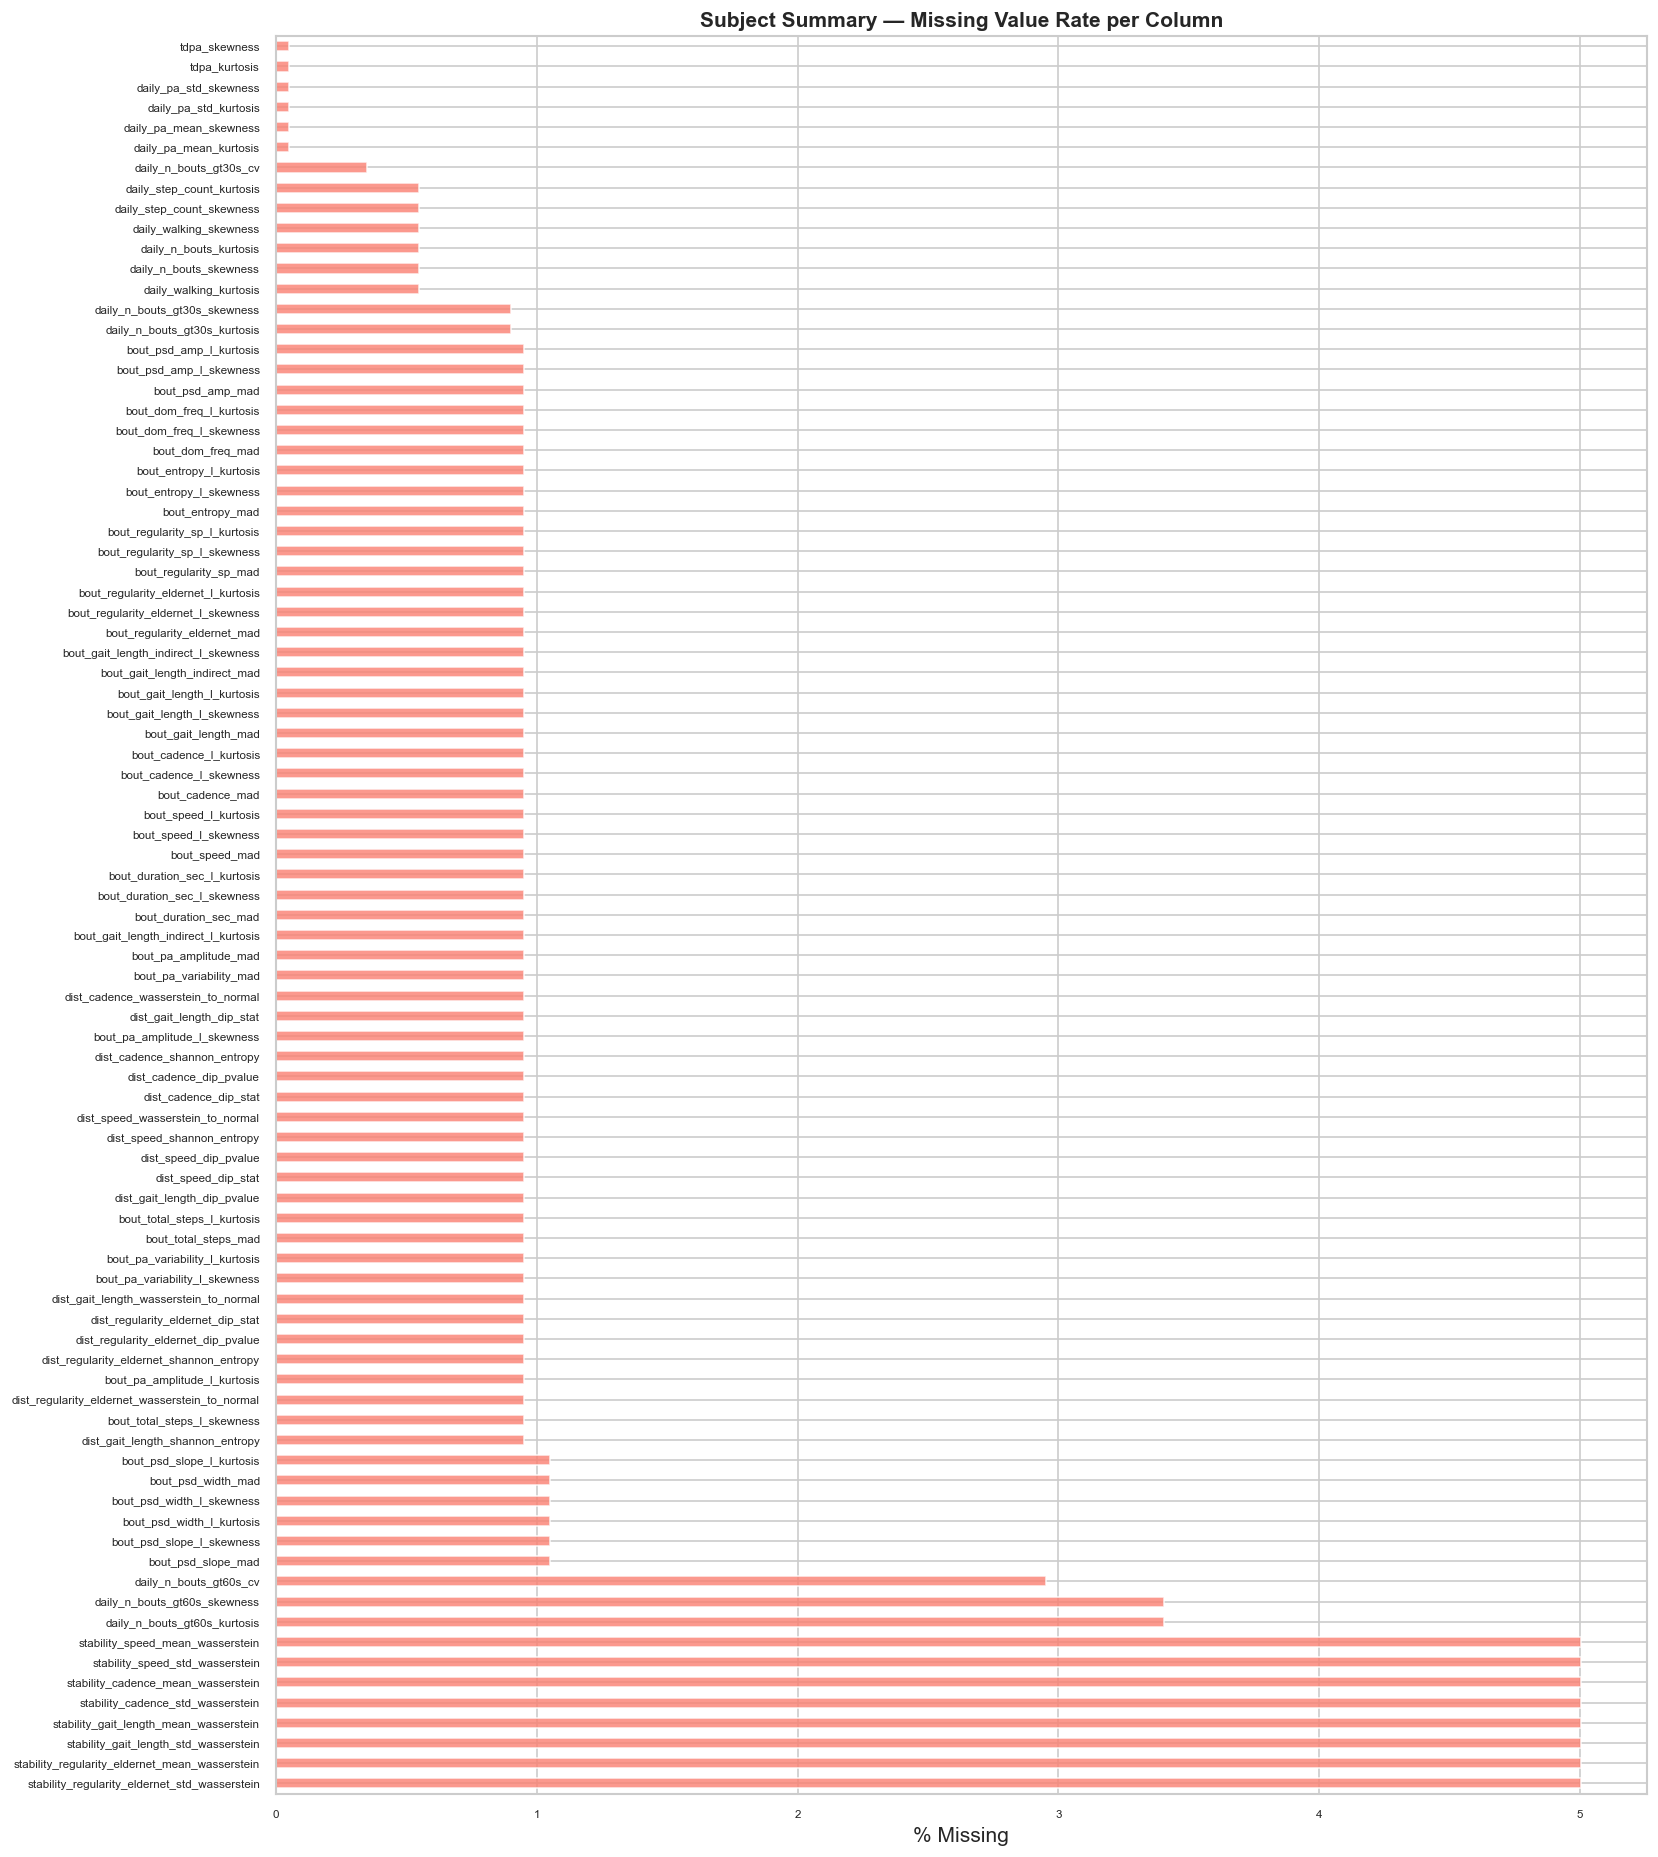

In [18]:
# ── Missing values in summary ─────────────────────────────────────────────────
miss_s = summary.isnull().mean() * 100
miss_s = miss_s[miss_s > 0].sort_values(ascending=False)

if miss_s.empty:
    print('No missing values in subject summary.')
else:
    print(f'{len(miss_s)} columns have missing values.')

    fig, ax = plt.subplots(figsize=(14, max(4, len(miss_s) * 0.18)))
    miss_s.plot.barh(ax=ax, color='salmon', alpha=0.8)
    ax.set_xlabel('% Missing')
    ax.set_title('Subject Summary — Missing Value Rate per Column', fontweight='bold')
    ax.tick_params(labelsize=7)
    plt.tight_layout()
    plt.show()

In [19]:
# ── Summary: key numeric columns ──────────────────────────────────────────────
SUMMARY_CORE = [
    'wear_days', 'n_bouts',
    'daily_walking_mean', 'daily_walking_std',
    'daily_step_count_mean',
    'bout_duration_sec_mean', 'bout_duration_sec_median',
    'bout_speed_median_mean', 'bout_speed_median_median',
    'bout_cadence_median_mean',
    'bout_gait_length_median_mean',
    'bout_regularity_eldernet_median_mean',
    'bout_bout_pa_mean_mean', 'bout_bout_pa_mean_median',
    'daily_pa_mean_mean', 'tdpa_mean',
]
SUMMARY_CORE = [c for c in SUMMARY_CORE if c in summary.columns]

display(
    summary[SUMMARY_CORE]
    .describe(percentiles=[.05, .25, .5, .75, .95])
    .T.round(3)
    .style.background_gradient(cmap='Blues', subset=['mean', 'std'])
)

,count,mean,std,min,5%,25%,50%,75%,95%,max
wear_days,1998.000000,11.758000,3.426000,3.000000,9.000000,10.000000,11.000000,13.000000,19.000000,27.000000
n_bouts,1998.000000,1152.756000,563.065000,7.000000,186.700000,758.250000,1160.500000,1522.500000,2102.600000,3287.000000
daily_walking_mean,1998.000000,50.923000,30.094000,0.283000,6.459000,27.891000,49.662000,69.736000,102.560000,196.394000
daily_walking_std,1998.000000,16.944000,11.068000,0.000000,2.734000,8.821000,14.927000,23.064000,37.256000,69.921000
daily_step_count_mean,1998.000000,4303.723000,2722.099000,18.750000,480.482000,2228.572000,4073.206000,5933.417000,9049.306000,18291.667000
bout_duration_sec_mean,1998.000000,26.188000,7.518000,12.048000,16.467000,21.351000,25.198000,29.360000,39.786000,72.957000
bout_duration_sec_median,1998.000000,16.513000,2.104000,10.000000,13.000000,15.000000,16.000000,18.000000,20.000000,42.000000
daily_pa_mean_mean,1998.000000,25.111000,80.781000,1.188000,5.648000,9.319000,12.683000,16.410000,31.219000,1740.819000
tdpa_mean,1998.000000,65088.194000,209385.468000,3080.112000,14639.205000,24153.828000,32875.371000,42533.679000,80919.501000,4512201.955000


## 7. Subject-level: Key Metric Distributions

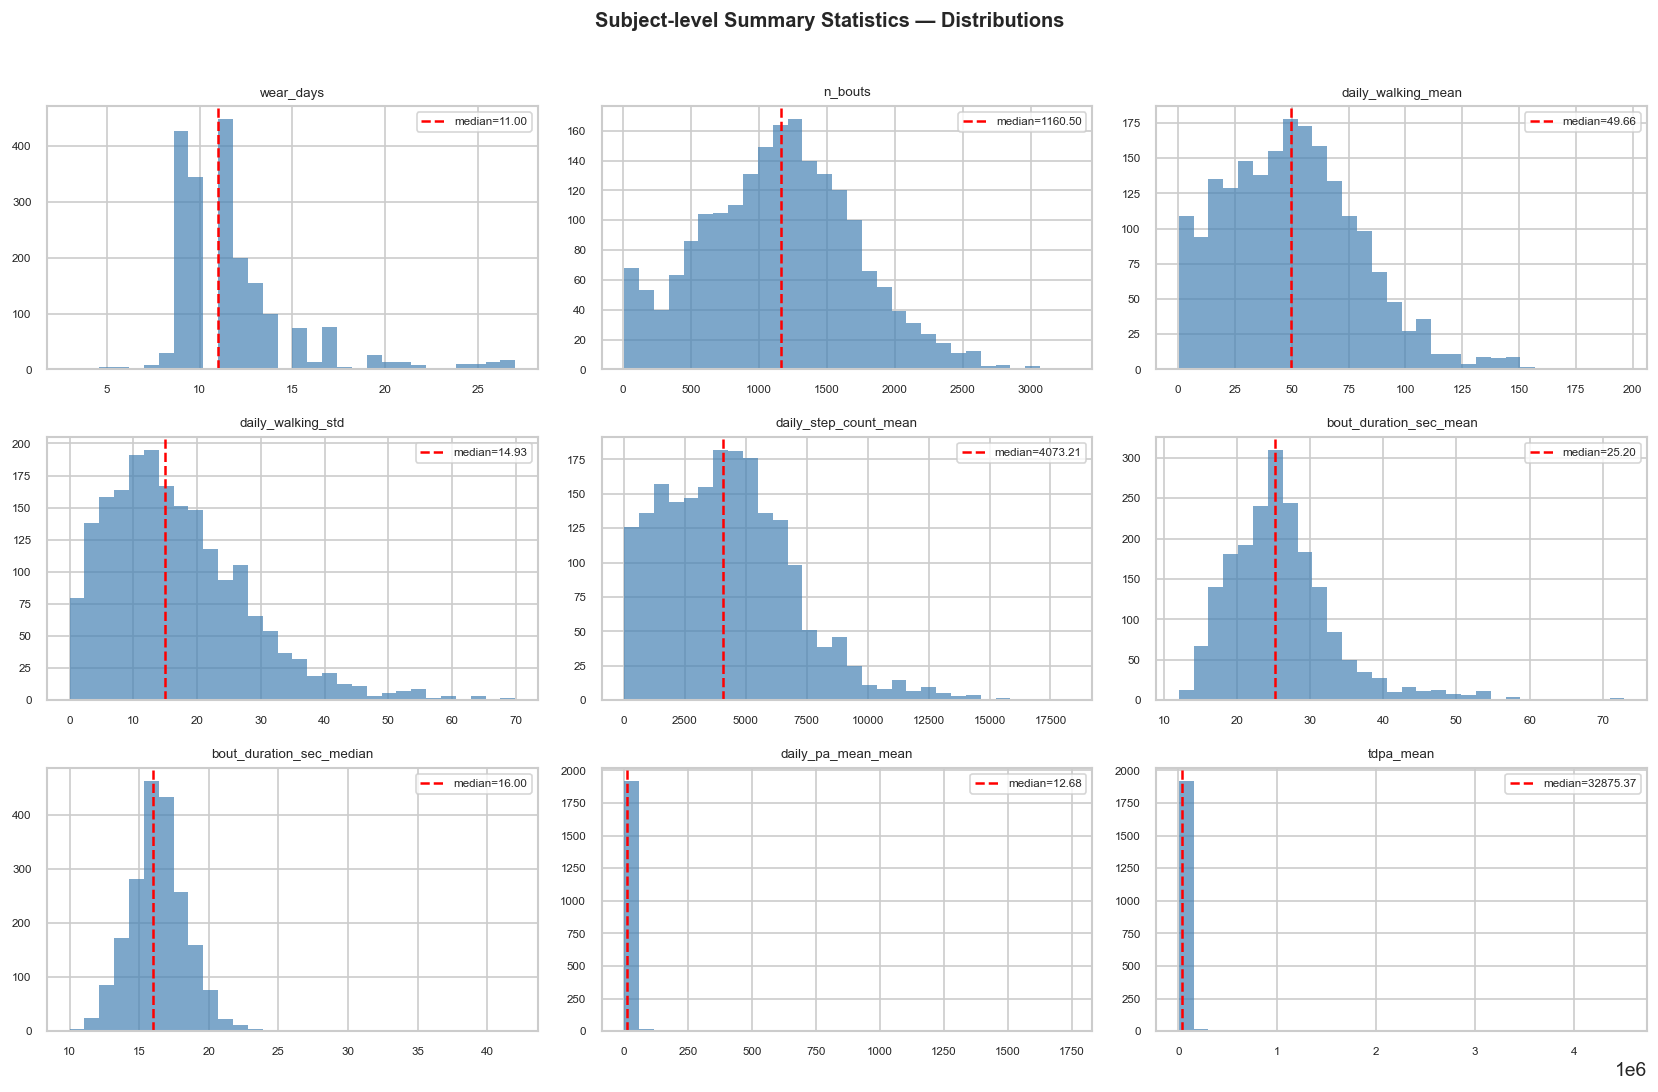

In [20]:
# ── Histograms for core subject-level aggregates ──────────────────────────────
ncols = 3
nrows = int(np.ceil(len(SUMMARY_CORE) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(14, nrows * 3))
axes = axes.flatten()

for ax, col in zip(axes, SUMMARY_CORE):
    data = summary[col].dropna()
    ax.hist(data, bins=30, color='steelblue', alpha=0.7, edgecolor='none')
    ax.axvline(data.median(), color='red', lw=1.5, ls='--', label=f'median={data.median():.2f}')
    ax.set_title(col, fontsize=8)
    ax.tick_params(labelsize=7)
    ax.legend(fontsize=7)

for ax in axes[len(SUMMARY_CORE):]:
    ax.set_visible(False)

fig.suptitle('Subject-level Summary Statistics — Distributions', fontsize=12, fontweight='bold', y=1.01)
fig.tight_layout()
plt.show()

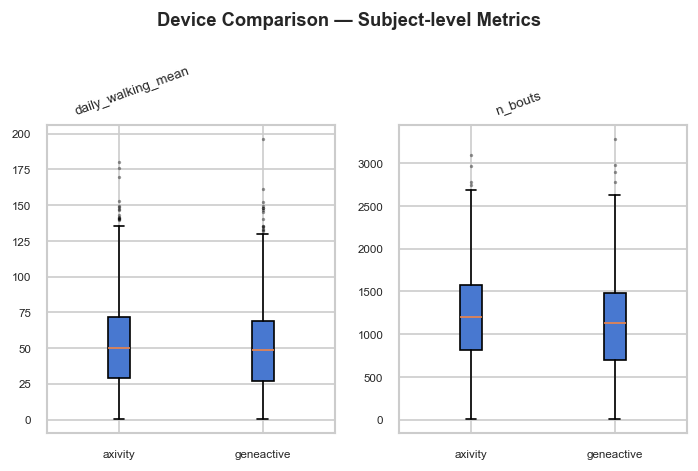

In [21]:
# ── Device comparison (if multi-device) ──────────────────────────────────────
if 'device' in summary.columns and summary['device'].nunique() > 1:
    compare_metrics = [
        'bout_speed_median_mean', 'bout_cadence_median_mean',
        'bout_gait_length_median_mean', 'bout_bout_pa_mean_mean',
        'daily_walking_mean', 'n_bouts'
    ]
    compare_metrics = [c for c in compare_metrics if c in summary.columns]

    fig, axes = plt.subplots(1, len(compare_metrics), figsize=(3 * len(compare_metrics), 4))
    if len(compare_metrics) == 1:
        axes = [axes]

    for ax, col in zip(axes, compare_metrics):
        data_by_dev = [grp[col].dropna().values for _, grp in summary.groupby('device')]
        labels = summary['device'].unique().tolist()
        ax.boxplot(data_by_dev, labels=labels, patch_artist=True,
                   flierprops=dict(marker='.', markersize=2, alpha=0.4))
        ax.set_title(col, fontsize=8, rotation=20, ha='right')
        ax.tick_params(labelsize=7)

    fig.suptitle('Device Comparison — Subject-level Metrics', fontsize=11, fontweight='bold')
    fig.tight_layout()
    plt.show()
else:
    print('Single device or no device column — skipping device comparison.')

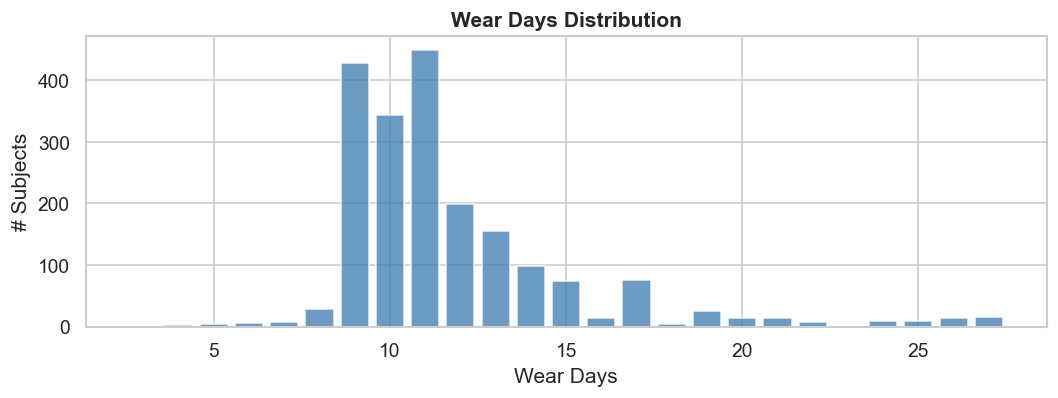

Subjects with < 3 wear days : 0
Subjects with < 7 wear days : 12


In [22]:
# ── Wear days distribution ────────────────────────────────────────────────────
if 'wear_days' in summary.columns:
    fig, ax = plt.subplots(figsize=(9, 3.5))
    wd = summary['wear_days'].value_counts().sort_index()
    ax.bar(wd.index, wd.values, color='steelblue', alpha=0.8)
    ax.set_xlabel('Wear Days')
    ax.set_ylabel('# Subjects')
    ax.set_title('Wear Days Distribution', fontweight='bold')
    plt.tight_layout()
    plt.show()

    print(f'Subjects with < 3 wear days : {(summary["wear_days"] < 3).sum()}')
    print(f'Subjects with < 7 wear days : {(summary["wear_days"] < 7).sum()}')

## 8. Subject-level: Outlier Subjects

In [23]:
# ── IQR outlier subjects per metric ──────────────────────────────────────────
subj_flag = pd.DataFrame(index=summary.index)
for col in SUMMARY_CORE:
    if col in summary.columns:
        subj_flag[col] = iqr_outlier_mask(summary[col].fillna(summary[col].median())).astype(int)

summary['n_outlier_flags'] = subj_flag.sum(axis=1)

id_col = 'sub_id' if 'sub_id' in summary.columns else summary.columns[0]

print('Top 15 subjects with most outlier flags:')
display(
    summary[[id_col] + (['device'] if 'device' in summary.columns else []) +
             SUMMARY_CORE + ['n_outlier_flags']]
    .sort_values('n_outlier_flags', ascending=False)
    .head(15)
    .reset_index(drop=True)
    .style.background_gradient(cmap='OrRd', subset=['n_outlier_flags'])
)

Top 15 subjects with most outlier flags:


,sub_id,device,wear_days,n_bouts,daily_walking_mean,daily_walking_std,daily_step_count_mean,bout_duration_sec_mean,bout_duration_sec_median,daily_pa_mean_mean,tdpa_mean,n_outlier_flags
0,35003982_02,axivity,12,2412,179.965278,51.348879,18291.666667,53.720978,19.000000,30.374319,78730.235590,6
1,44413199_01,axivity,24,1703,140.941667,68.546274,13793.300000,49.656489,20.000000,8.587066,22257.674165,5
2,70555991_02,axivity,9,1890,134.118519,40.828469,12973.222222,38.319577,19.000000,28.223210,73154.561151,4
3,17259824_1,geneactive,11,2205,161.306667,54.704020,13394.500000,43.892971,20.000000,22.999473,59614.633515,4
4,46317892_0,geneactive,9,2246,196.394444,26.953236,16595.555556,47.218611,23.000000,13.498438,34987.951670,4
5,65608216_6,geneactive,11,2893,152.480000,54.657675,12886.600000,31.623920,19.000000,21.781804,56458.436133,4
6,46614210_0,geneactive,11,1657,135.230303,51.929184,12419.818182,53.863609,18.000000,13.133782,34042.761894,4
7,41228878_8,geneactive,11,11,12.533333,0.000000,1264.000000,68.363636,42.000000,212.567112,550973.953343,4
8,72277580_3,geneactive,11,2177,129.748485,45.323374,12394.727273,39.335783,18.000000,30.715891,79615.590191,4
9,17259824_2,geneactive,13,2125,148.087879,53.271751,12673.000000,45.994353,21.000000,13.673515,35441.751768,4


In [24]:
# ── Low mean PA subjects ──────────────────────────────────────────────────────
pa_col = 'bout_bout_pa_mean_mean'
if pa_col in summary.columns:
    LOW_SUBJ_PA = 0.9
    low_pa_subj = summary[summary[pa_col] < LOW_SUBJ_PA]
    print(f'Subjects with mean bout_pa_mean < {LOW_SUBJ_PA} g: {len(low_pa_subj)}')
    if not low_pa_subj.empty:
        cols_show = [id_col, pa_col, 'wear_days', 'n_bouts',
                     'bout_speed_median_mean', 'bout_cadence_median_mean']
        cols_show = [c for c in cols_show if c in low_pa_subj.columns]
        display(low_pa_subj[cols_show].reset_index(drop=True))

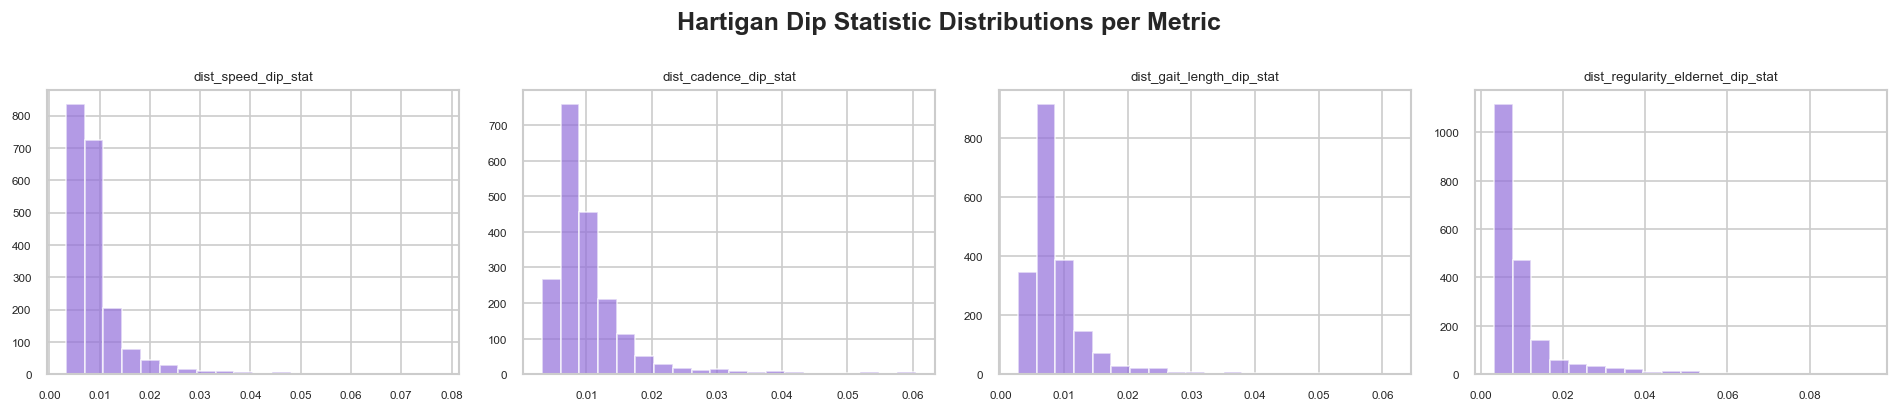

In [25]:
# ── Distribution shape metrics (dip stat, wasserstein) ────────────────────────
dist_cols = [c for c in summary.columns if c.startswith('dist_') and c.endswith('_dip_stat')]

if dist_cols:
    ncols = min(4, len(dist_cols))
    nrows = int(np.ceil(len(dist_cols) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3.5 * nrows))
    axes = np.array(axes).flatten()

    for ax, col in zip(axes, dist_cols):
        data = summary[col].dropna()
        ax.hist(data, bins=20, color='mediumpurple', alpha=0.7)
        ax.set_title(col, fontsize=8)
        ax.tick_params(labelsize=7)

    for ax in axes[len(dist_cols):]:
        ax.set_visible(False)

    fig.suptitle('Hartigan Dip Statistic Distributions per Metric', fontweight='bold')
    fig.tight_layout()
    plt.show()
else:
    print('No dist_* dip_stat columns found — run aggregate_subjects.py with diptest installed.')

## 9. Cross-level: Bout Counts vs Summary Stats

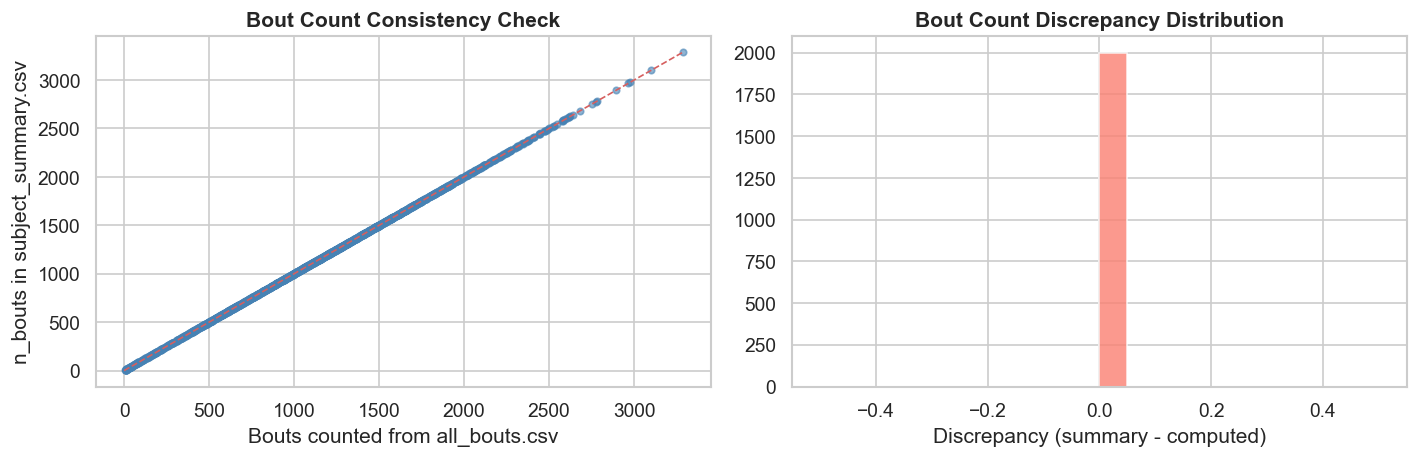

All bout counts match exactly.


In [26]:
# ── Bout counts per subject from bout-level vs summary n_bouts ────────────────
if 'subject_id' in bouts.columns and id_col in summary.columns:
    bout_counts = bouts.groupby('subject_id').size().reset_index(name='n_bouts_computed')
    check = summary[[id_col, 'n_bouts']].merge(
        bout_counts, left_on=id_col, right_on='subject_id', how='left'
    )
    check['discrepancy'] = check['n_bouts'] - check['n_bouts_computed']

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].scatter(check['n_bouts_computed'], check['n_bouts'], s=15, alpha=0.6, color='steelblue')
    lim = max(check[['n_bouts','n_bouts_computed']].max())
    axes[0].plot([0, lim], [0, lim], 'r--', lw=1)
    axes[0].set_xlabel('Bouts counted from all_bouts.csv')
    axes[0].set_ylabel('n_bouts in subject_summary.csv')
    axes[0].set_title('Bout Count Consistency Check', fontweight='bold')

    axes[1].hist(check['discrepancy'].dropna(), bins=20, color='salmon', alpha=0.8)
    axes[1].set_xlabel('Discrepancy (summary - computed)')
    axes[1].set_title('Bout Count Discrepancy Distribution', fontweight='bold')

    fig.tight_layout()
    plt.show()

    nonzero = check[check['discrepancy'].abs() > 0]
    if nonzero.empty:
        print('All bout counts match exactly.')
    else:
        print(f'{len(nonzero)} subjects have discrepant bout counts:')
        display(nonzero.head(10))
else:
    print('Cannot cross-check bout counts — subject_id not found in bouts or summary.')

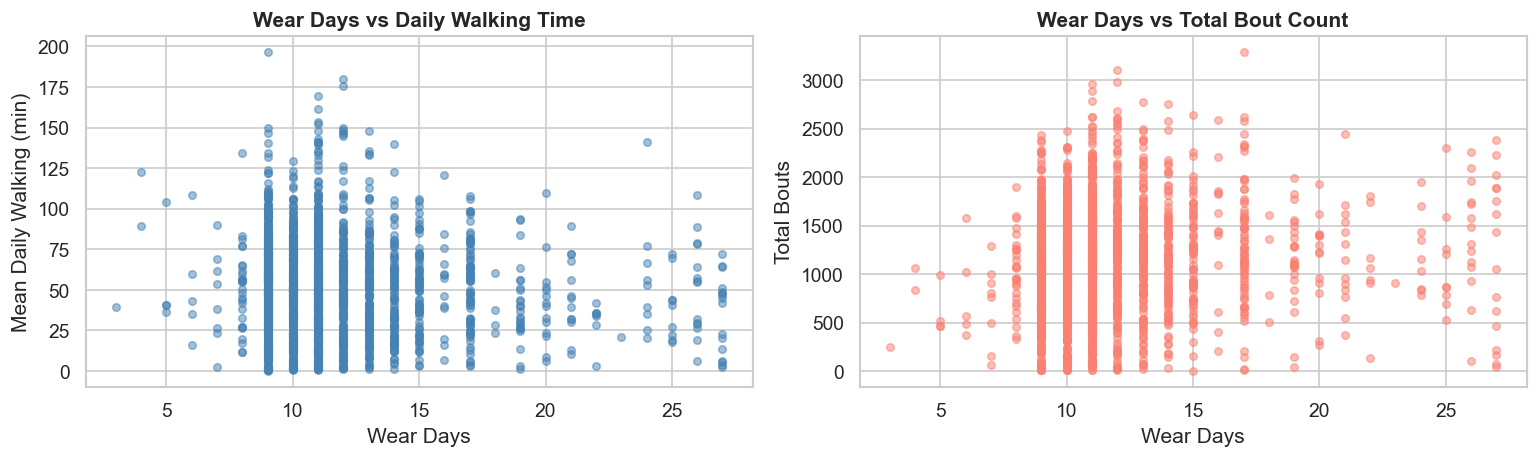

In [27]:
# ── Wear days vs walking time ─────────────────────────────────────────────────
if 'wear_days' in summary.columns and 'daily_walking_mean' in summary.columns:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    axes[0].scatter(summary['wear_days'], summary['daily_walking_mean'],
                    s=20, alpha=0.5, color='steelblue')
    axes[0].set_xlabel('Wear Days')
    axes[0].set_ylabel('Mean Daily Walking (min)')
    axes[0].set_title('Wear Days vs Daily Walking Time', fontweight='bold')

    if 'n_bouts' in summary.columns:
        axes[1].scatter(summary['wear_days'], summary['n_bouts'],
                        s=20, alpha=0.5, color='salmon')
        axes[1].set_xlabel('Wear Days')
        axes[1].set_ylabel('Total Bouts')
        axes[1].set_title('Wear Days vs Total Bout Count', fontweight='bold')

    fig.tight_layout()
    plt.show()

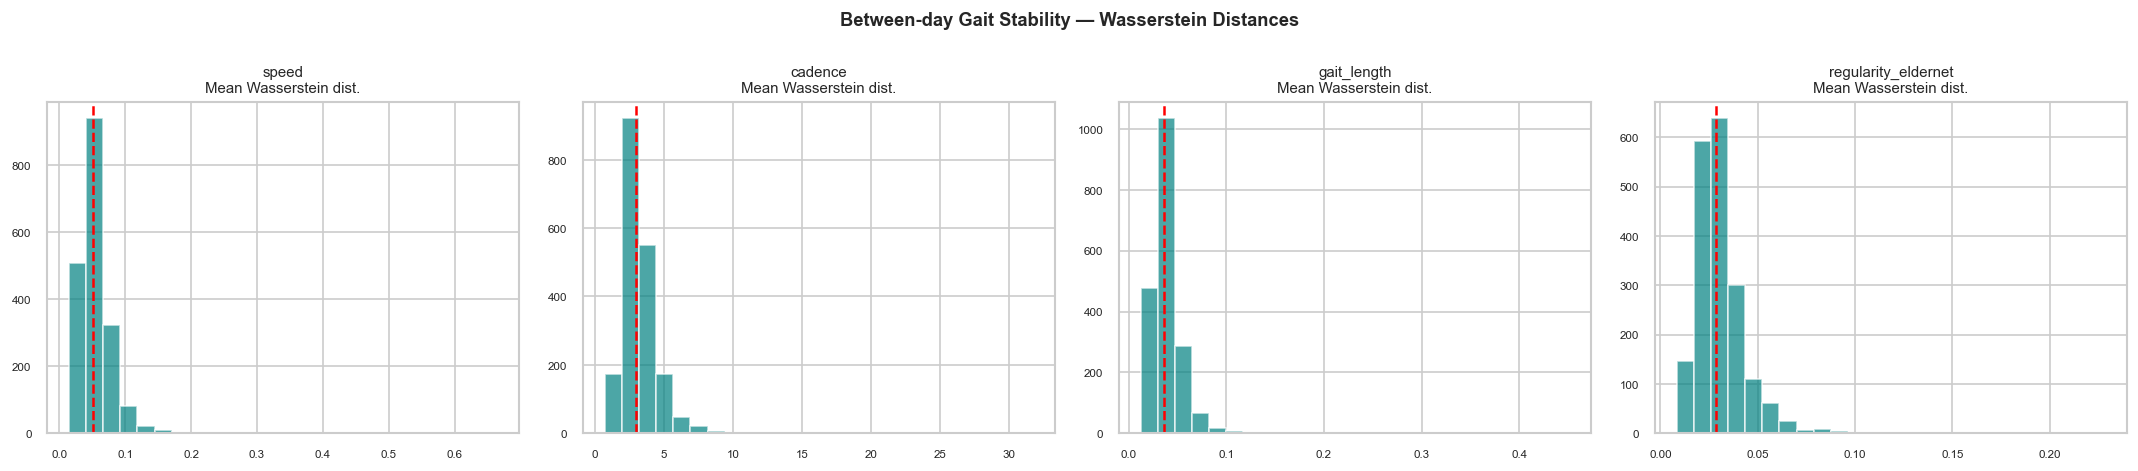

In [28]:
# ── Between-day stability overview ───────────────────────────────────────────
stab_cols = [c for c in summary.columns if 'stability_' in c and 'mean_wasserstein' in c]

if stab_cols:
    fig, axes = plt.subplots(1, len(stab_cols), figsize=(4.5 * len(stab_cols), 4))
    if len(stab_cols) == 1:
        axes = [axes]

    for ax, col in zip(axes, stab_cols):
        data = summary[col].dropna()
        ax.hist(data, bins=25, color='teal', alpha=0.7)
        ax.axvline(data.median(), color='red', lw=1.5, ls='--')
        metric_name = col.replace('stability_', '').replace('_mean_wasserstein', '')
        ax.set_title(f'{metric_name}\nMean Wasserstein dist.', fontsize=9)
        ax.tick_params(labelsize=7)

    fig.suptitle('Between-day Gait Stability — Wasserstein Distances', fontsize=11, fontweight='bold')
    fig.tight_layout()
    plt.show()
else:
    print('No between-day stability columns found.')

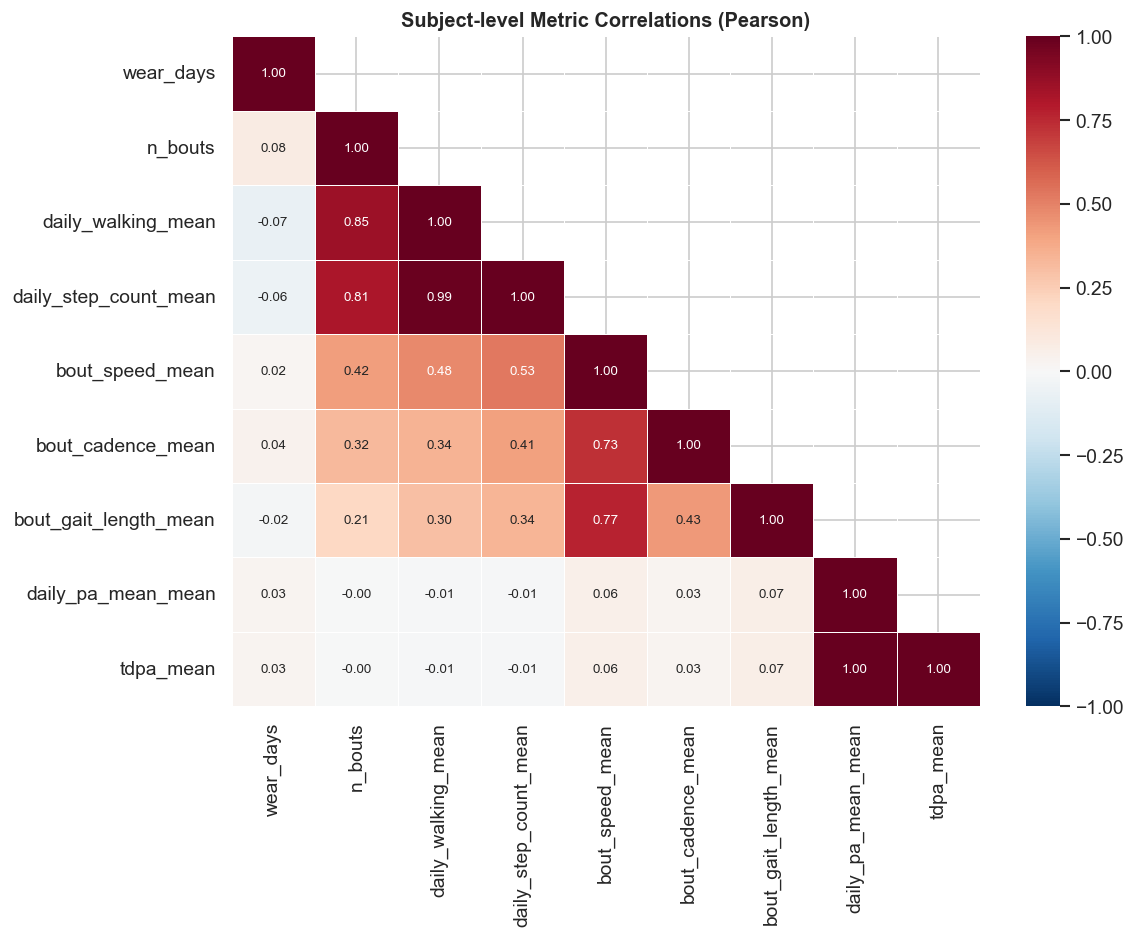

In [29]:
# ── Subject-level correlation heatmap (core metrics only) ─────────────────────
subj_corr_cols = [
    'wear_days', 'n_bouts', 'daily_walking_mean', 'daily_step_count_mean',
    'bout_speed_mean', 'bout_cadence_mean',
    'bout_gait_length_mean', 'bout_regularity_eldernet_median_mean',
    'bout_bout_pa_mean_mean', 'daily_pa_mean_mean', 'tdpa_mean',
]
subj_corr_cols = [c for c in subj_corr_cols if c in summary.columns]

corr_s = summary[subj_corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_s, dtype=bool), k=1)
sns.heatmap(
    corr_s, mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    linewidths=0.4, ax=ax, annot_kws={'size': 8}
)
ax.set_title('Subject-level Metric Correlations (Pearson)', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

## Summary

This cell prints a concise quality report.

In [30]:
print('=' * 60)
print('PIPELINE OUTPUT QUALITY REPORT')
print('=' * 60)
print(f'Total bouts            : {len(bouts):,}')
print(f'Total subjects         : {len(summary):,}')
if 'device' in bouts.columns:
    print(f'Devices                : {bouts["device"].unique().tolist()}')
if 'bout_pa_mean' in bouts.columns:
    print(f'Low bout_pa_mean (<0.8g): {(bouts["bout_pa_mean"] < 0.8).sum():,} ({(bouts["bout_pa_mean"] < 0.8).mean()*100:.2f}%)')
print(f'Bouts flagged ≥4 metrics: {(bouts["n_outlier_flags"] >= 4).sum():,}')
miss_pct_bouts = bouts[BOUT_METRICS].isnull().mean().mean() * 100
print(f'Avg. missing % (bouts)  : {miss_pct_bouts:.2f}%')
miss_pct_summ  = summary[SUMMARY_CORE].isnull().mean().mean() * 100
print(f'Avg. missing % (summary): {miss_pct_summ:.2f}%')
print('=' * 60)

PIPELINE OUTPUT QUALITY REPORT
Total bouts            : 2,303,207
Total subjects         : 1,998
Devices                : ['axivity', 'geneactive']
Bouts flagged ≥4 metrics: 97,637
Avg. missing % (bouts)  : 0.38%
Avg. missing % (summary): 0.00%


In [40]:
import plotly.express as px
import pandas as pd

# 1. Automatically find clinical exemplars using the summary metrics ('sub_id')
# Patient A: Lowest Dip Statistic (Most Unimodal/Normal)
unimodal_sub = summary.nsmallest(1, 'dist_speed_dip_stat')['sub_id'].values[0]
# Patient B: Highest Dip Statistic (Most Multimodal/Bifurcated)
multimodal_sub = summary.nlargest(1, 'dist_speed_dip_stat')['sub_id'].values[0]

# 2. Filter the bout-level data using 'subject_id'
exemplar_bouts = bouts[bouts['subject_id'].isin([unimodal_sub, multimodal_sub])].copy()

# 3. Create readable clinical labels
def label_subject(row):
    if row['subject_id'] == unimodal_sub:
        return f"Patient A: Unimodal Gait<br>(One consistent pace)"
    else:
        return f"Patient B: Multimodal Gait<br>(Two distinct walking modes)"

exemplar_bouts['Clinical Phenotype'] = exemplar_bouts.apply(label_subject, axis=1)

# 4. Plot the raw distributions
fig1 = px.histogram(
    exemplar_bouts, 
    x="speed", 
    color="Clinical Phenotype",
    barmode="overlay",
    histnorm='probability density',
    marginal="violin", # Adds a nice shape summary at the top
    title="What is 'Distributional Shape'? (Multimodal vs. Unimodal Walking)",
    labels={"speed": "Bout Walking Speed (m/s)"},
    color_discrete_sequence=['#2ca02c', '#d62728'] # Green for normal, Red for irregular
)

fig1.update_layout(template="plotly_white", height=500, legend_title_text="")
fig1.update_traces(opacity=0.65)
fig1.show()

In [41]:
import plotly.express as px

# 1. Automatically find clinical exemplars ('sub_id')
# Patient C: Lowest Wasserstein (Highly stable day-to-day)
stable_sub = summary.nsmallest(1, 'stability_speed_mean_wasserstein')['sub_id'].values[0]
# Patient D: Highest Wasserstein (Highly erratic/unstable day-to-day)
unstable_sub = summary.nlargest(1, 'stability_speed_mean_wasserstein')['sub_id'].values[0]

# 2. Filter bout data using 'subject_id' (limit to first 7 days for clean visualization)
stability_bouts = bouts[(bouts['subject_id'].isin([stable_sub, unstable_sub])) & (bouts['day'] <= 7)].copy()

# 3. Create readable clinical labels mapping 'subject_id'
stability_bouts['Clinical Phenotype'] = stability_bouts['subject_id'].map({
    stable_sub: "Patient C: Stable (Low Wasserstein)",
    unstable_sub: "Patient D: Unstable (High Wasserstein)"
})

# Ensure 'day' is treated as a category for the axis
stability_bouts['Day of Recording'] = "Day " + stability_bouts['day'].astype(int).astype(str)
stability_bouts = stability_bouts.sort_values(['Clinical Phenotype', 'day'])

# 4. Use a Violin plot to show how the distribution shifts (or doesn't) across days
fig2 = px.violin(
    stability_bouts, 
    x="Day of Recording", 
    y="speed", 
    color="Clinical Phenotype",
    facet_row="Clinical Phenotype", # Splits the stable and unstable into two rows
    box=True, 
    title="What is 'Day-to-Day Stability'? (Distribution Shifts over 1 Week)",
    labels={"speed": "Bout Walking Speed (m/s)"},
    color_discrete_sequence=['#1f77b4', '#ff7f0e']
)

# Clean up the layout for a clinical presentation
fig2.update_layout(
    template="plotly_white", 
    height=700, 
    showlegend=False
)
# Remove the facet row text annotations that Plotly adds by default for a cleaner look
fig2.for_each_annotation(lambda a: a.update(text=a.text.split("=")[-1]))
fig2.show()

In [37]:
import pandas as pd

tod_cols = [
    'tod_morning_proportion', 
    'tod_afternoon_proportion', 
    'tod_evening_proportion', 
    'tod_night_proportion'
]

# ---- Plot A: Cohort Average Donut Chart ----
tod_means = summary[tod_cols].mean().reset_index()
tod_means.columns = ['Time of Day', 'Proportion']
# Clean up labels for display
tod_means['Time of Day'] = tod_means['Time of Day'].str.replace('tod_', '').str.replace('_proportion', '').str.title()

fig_pie = px.pie(
    tod_means, 
    values='Proportion', 
    names='Time of Day',
    title="Average Time-of-Day Distribution of Bouts (Cohort Level)",
    hole=0.45,
    color_discrete_sequence=px.colors.qualitative.Pastel
)
fig_pie.update_traces(textposition='inside', textinfo='percent+label')
fig_pie.update_layout(template="plotly_white", height=500)
fig_pie.show()

# ---- Plot B: Individual Participant Stacked Bar ----
# Sorting participants by morning proportion to make the chart readable
sorted_summary = summary.sort_values(by='tod_morning_proportion', ascending=False).dropna(subset=tod_cols)

fig_bar = go.Figure()
colors = ['#FF9999', '#FFCC99', '#99CCFF', '#9999FF'] # Morning, Afternoon, Evening, Night

for i, col in enumerate(tod_cols):
    name = col.replace('tod_', '').replace('_proportion', '').title()
    fig_bar.add_trace(go.Bar(
        x=sorted_summary['sub_id'].astype(str),
        y=sorted_summary[col],
        name=name,
        marker_color=colors[i]
    ))

fig_bar.update_layout(
    title="Time-of-Day Proportions per Participant",
    xaxis_title="Participant (Subject ID)",
    yaxis_title="Proportion of Bouts",
    barmode='stack',
    template="plotly_white",
    height=600,
    xaxis={'categoryorder':'total descending', 'showticklabels': False} # Hide labels if too many subjects
)
fig_bar.show()